In [1]:
# Upload your dataset from local machine
from google.colab import files
uploaded = files.upload() # This will open a file chooser to upload your CSV


# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
# Load the CSV file into a DataFrame
df = pd.read_csv("/content/Sample - Superstore.csv", encoding='latin1')  # replace with your actual CSV file name
df.head()  # Display the first 5 rows

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Convert 'Order Date' column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Check for missing values
print(df.isnull().sum())

# Fill missing values (if any) with 0
df.fillna(0, inplace=True)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


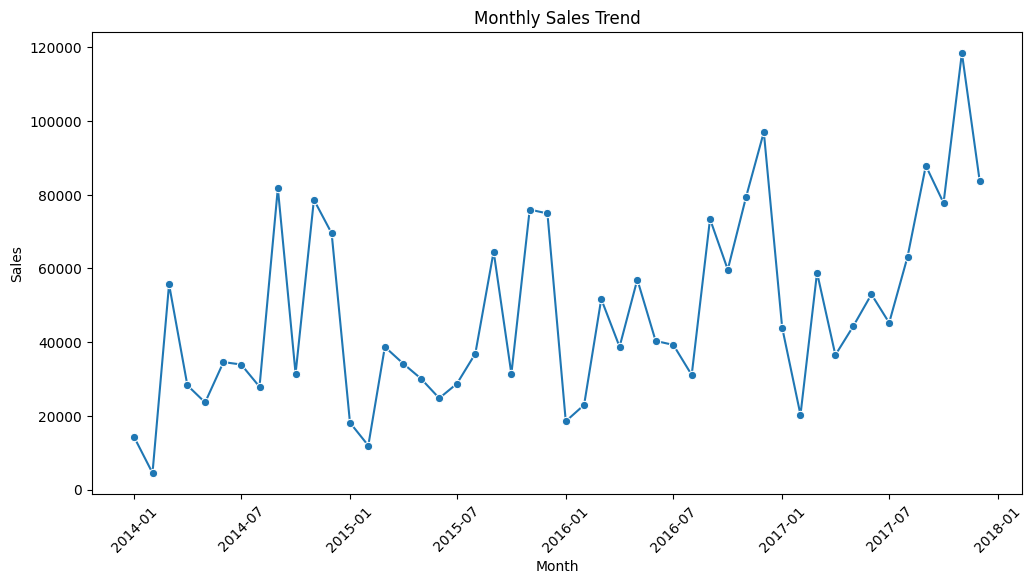

In [8]:
# Extract month from order date and convert to datetime for plotting
df['Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()

# Calculate monthly total sales
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

# Plot sales trend
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', marker='o')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


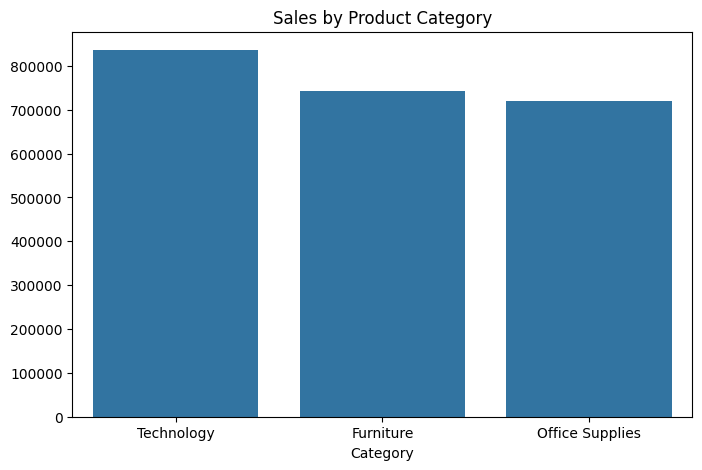

In [9]:
# Total sales by product category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# Bar plot for category sales
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Product Category")
plt.show()

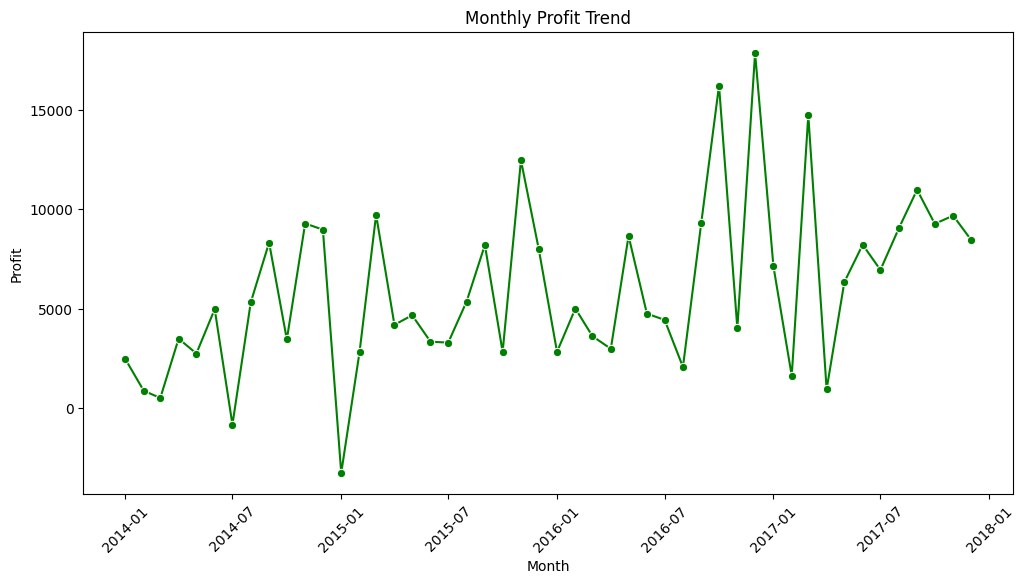

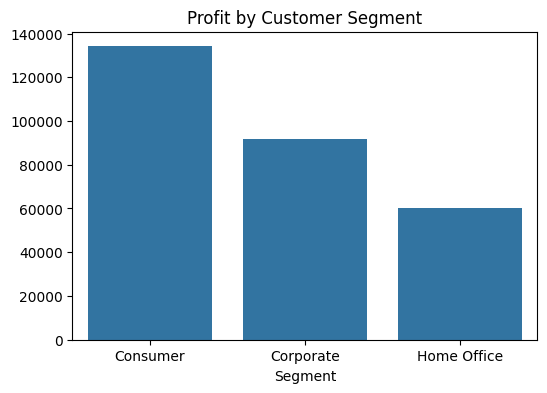

In [10]:
# Monthly profit trend
monthly_profit = df.groupby('Month')['Profit'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_profit, x='Month', y='Profit', marker='o', color='green')
plt.title("Monthly Profit Trend")
plt.xticks(rotation=45)
plt.show()

# Profit by customer segment
segment_profit = df.groupby('Segment')['Profit'].sum()
plt.figure(figsize=(6,4))
sns.barplot(x=segment_profit.index, y=segment_profit.values)
plt.title("Profit by Customer Segment")
plt.show()

In [11]:
# Top 10 profitable products
top_profit_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [12]:
fig = px.bar(df.groupby('Sub-Category')['Sales'].sum().reset_index(),
             x='Sub-Category', y='Sales',
             title="Sales by Sub-Category",
             color='Sales')
fig.show()

In [13]:
# Calculate profit margin
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

# Average profit margin by category
profit_margin_by_category = df.groupby('Category')['Profit Margin'].mean()
print(profit_margin_by_category)

Category
Furniture           3.878353
Office Supplies    13.803029
Technology         15.613805
Name: Profit Margin, dtype: float64
